# Movie Recommendation System

**Problem.** Build a movie recommendation system combining two complementary approaches:
content-based filtering (similarity between movies by genre, director and cast) and
collaborative filtering (behavior of similar users, via SVD). Both are formally evaluated and
compared against each other, not just assessed qualitatively. The system must also handle the
cold start case: a new user with no rating history, or a movie with no interactions. A
recommender that only works for well-established users and titles has limited real-world
value.

**Value.** Covers the full cycle of a recommendation project, end to end: data cleaning and
EDA grounded in hypothesis testing rather than visual impression, two distinct recommendation
approaches, formal evaluation with standard retrieval metrics (Precision@K, Recall@K), a
direct comparison between approaches, and deployment as a usable application. This mirrors
what a production recommender project actually requires, beyond a single model trained and
left in a notebook.

**Dataset.** [The Movies Dataset](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset)
(Kaggle, compiled from TMDB and MovieLens), downloaded via `kagglehub`. It ships as several
related files:

- `movies_metadata.csv`: one row per movie (~45,000), with title, genres, budget, revenue,
  runtime, original language, release date, production companies/countries, vote average and
  vote count, popularity, overview, and status. This is the main content source.
- `credits.csv`: cast and crew per movie (JSON-encoded), used in the content-based stage to
  extract director and lead actors.
- `keywords.csv`: plot keywords per movie (JSON-encoded), an optional content feature.
- `links.csv` / `links_small.csv`: mapping between MovieLens `movieId`, IMDb `imdbId` and
  TMDB `tmdbId`, used to join ratings with metadata. `links_small.csv` covers a subset of
  ~9,000 movies.
- `ratings.csv` / `ratings_small.csv`: user ratings (`userId`, `movieId`, `rating`,
  `timestamp`) for collaborative filtering. The full file has on the order of 26 million
  ratings from ~270,000 users; the small version has 100,000 ratings from 700 users, scoped to
  the ~9,000 movies in `links_small.csv`.

The full `ratings.csv` does not fit in memory on this machine, so this project uses
`ratings_small.csv` and `links_small.csv` throughout. That decision also fixes the project's
scope: the ~9,000 movies referenced by `links_small.csv` are the universe for every later
step (EDA, content-based features, and collaborative filtering), even though
`movies_metadata.csv` itself covers ~45,000.

**Approach.** Data loading and cleaning, followed by EDA with business questions and
statistical tests (correlation, group comparison, categorical association) on the ~9,000-movie
subset. Content-based filtering with feature engineering (genre, director, cast) and cosine
similarity, with an explicit strategy for cold start. Collaborative filtering with SVD on
`ratings_small.csv`, evaluated with Precision@K / Recall@K and compared against the
content-based approach through A/B testing.

# Libraries

In [843]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
import random 
from scipy.stats import pearsonr, spearmanr, ttest_ind, mannwhitneyu, f_oneway, kruskal, chi2_contingency
import kagglehub

from ast import literal_eval

# Reproducibility

In [844]:
SEED = 123
np.random.seed(SEED)
random.seed(SEED)

# Data 

In [845]:
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/alejandro/.cache/kagglehub/datasets/rounakbanik/the-movies-dataset/versions/7


In [846]:
credits = pd.read_csv(f"{path}/credits.csv")
keywords = pd.read_csv(f"{path}/keywords.csv")
links = pd.read_csv(f"{path}/links_small.csv")
ratings = pd.read_csv(f"{path}/ratings_small.csv")
metadata = pd.read_csv(f"{path}/movies_metadata.csv")

/tmp/ipykernel_104904/1848752738.py:5: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f"{path}/movies_metadata.csv")


## Credits

In [847]:
credits.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [848]:
credits.info()

<class 'pandas.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   cast    45476 non-null  str  
 1   crew    45476 non-null  str  
 2   id      45476 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.0 MB


## Keywords

In [849]:
keywords.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [850]:
keywords.info()

<class 'pandas.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        46419 non-null  int64
 1   keywords  46419 non-null  str  
dtypes: int64(1), str(1)
memory usage: 725.4 KB


## Links

In [851]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [852]:
links.info()

<class 'pandas.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9125 non-null   int64  
 1   imdbId   9125 non-null   int64  
 2   tmdbId   9112 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 214.0 KB


## Ratings

In [853]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [854]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


## Metadata

In [855]:
metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [856]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date           45379 non-null  str    
 15  revenue      

# Cleaning Data

## Duplicated

`metadata`, `credits`, `keywords` and `links` are dimension tables merged on assumed-unique
keys; an unnoticed duplicate silently multiplies rows on merge, so each is checked first.
`metadata` is checked on both `id` and `imdb_id`, since it's the hinge between the content-side
merge (by `id`) and the ratings-side merge (by `imdb_id`); the others only need the one key
they're joined on. `ratings` is a fact table: repeated `movieId`/`userId` are expected, so
only exact full-row duplicates are checked there.

### Credits

In [857]:
credits.duplicated().sum()

np.int64(37)

In [858]:
credits[credits['id'].duplicated(keep=False)].sort_values('id').head(10)

,cast,crew,id
25950,"[{'cast_id': 12, 'character': 'The Creature', ...","[{'credit_id': '52fe4380c3a36847f80590dd', 'de...",3057
25885,"[{'cast_id': 12, 'character': 'The Creature', ...","[{'credit_id': '52fe4380c3a36847f80590dd', 'de...",3057
5865,"[{'cast_id': 15, 'character': 'Chuck Barris', ...","[{'credit_id': '52fe43e2c3a36847f80760b5', 'de...",4912
33838,"[{'cast_id': 15, 'character': 'Chuck Barris', ...","[{'credit_id': '52fe43e2c3a36847f80760a9', 'de...",4912
9165,"[{'cast_id': 11, 'character': 'Jef Costello', ...","[{'credit_id': '52fe440ac3a36847f807ee01', 'de...",5511
7345,"[{'cast_id': 11, 'character': 'Jef Costello', ...","[{'credit_id': '52fe440ac3a36847f807ee01', 'de...",5511
25969,"[{'cast_id': 11, 'character': 'Mike Gaucher / ...","[{'credit_id': '52fe44b8c3a36847f80a6389', 'de...",8767
25895,"[{'cast_id': 11, 'character': 'Mike Gaucher / ...","[{'credit_id': '52fe44b8c3a36847f80a6389', 'de...",8767
25893,"[{'cast_id': 1, 'character': 'Churchill', 'cre...","[{'credit_id': '52fe4527c3a36847f80bf5e5', 'de...",9755
25967,"[{'cast_id': 1, 'character': 'Churchill', 'cre...","[{'credit_id': '52fe4527c3a36847f80bf5e5', 'de...",9755


In [859]:
credits.drop_duplicates(inplace=True)


In [860]:
print("Number of unique IDs", credits['id'].nunique())
print("Number of rows", credits.shape[0])

Number of unique IDs 45432
Number of rows 45439


In [861]:
dup_id = credits['id'].duplicated(keep=False)
dup_full = credits.duplicated(keep=False)
credits[dup_id & ~dup_full].sort_values('id')

,cast,crew,id
5865,"[{'cast_id': 15, 'character': 'Chuck Barris', ...","[{'credit_id': '52fe43e2c3a36847f80760b5', 'de...",4912
33838,"[{'cast_id': 15, 'character': 'Chuck Barris', ...","[{'credit_id': '52fe43e2c3a36847f80760a9', 'de...",4912
26638,"[{'cast_id': 1, 'character': 'Gerard Carriere'...","[{'credit_id': '52fe47bfc3a368484e0d77bf', 'de...",69234
9576,"[{'cast_id': 1, 'character': 'Gerard Carriere'...","[{'credit_id': '5468acec22136e68c9000d53', 'de...",69234
38882,"[{'cast_id': 1004, 'character': 'Luke Oarum', ...","[{'credit_id': '52fe4a269251416c750df61d', 'de...",99080
16167,"[{'cast_id': 1004, 'character': 'Luke Oarum', ...","[{'credit_id': '52fe4a269251416c750df623', 'de...",99080
23533,"[{'cast_id': 3, 'character': 'Camille Claudel'...","[{'credit_id': '577ed5389251416976004432', 'de...",110428
4356,"[{'cast_id': 3, 'character': 'Camille Claudel'...","[{'credit_id': '52fe4ad6c3a36847f81e461b', 'de...",110428
30013,"[{'cast_id': 4, 'character': 'Mihoko Nakagawa'...","[{'credit_id': '56365ed9925141285701b06e', 'de...",132641
838,"[{'cast_id': 4, 'character': 'Mihoko Nakagawa'...","[{'credit_id': '52fe4b9ac3a368484e190d25', 'de...",132641


In [862]:
credits = credits.drop_duplicates(subset='id', keep='first')


In [863]:
print("Number of unique IDs", credits['id'].nunique())
print("Number of rows", credits.shape[0])

Number of unique IDs 45432
Number of rows 45432


In [864]:
credits.duplicated().sum()

np.int64(0)

37 exact duplicates dropped. Remaining `id` repeats had identical `cast` but a different
`crew.credit_id`, TMDB's internal record id, not content, consistent with the same movie
scraped twice. Resolved with `keep='first'`: 45,476 to 45,432 rows, `id` now unique.

### Keywords

In [865]:
keywords.duplicated().sum()

np.int64(987)

In [866]:
keywords[keywords['id'].duplicated(keep=False)].sort_values('id').head(20)


,id,keywords
37095,1998,"[{'id': 417, 'name': 'corruption'}, {'id': 612..."
36138,1998,"[{'id': 417, 'name': 'corruption'}, {'id': 612..."
36822,3025,"[{'id': 212, 'name': 'london england'}, {'id':..."
35865,3025,"[{'id': 212, 'name': 'london england'}, {'id':..."
36956,3692,"[{'id': 470, 'name': 'spy'}, {'id': 591, 'name..."
35999,3692,"[{'id': 470, 'name': 'spy'}, {'id': 591, 'name..."
36631,4459,"[{'id': 1233, 'name': 'composer'}, {'id': 3423..."
35674,4459,"[{'id': 1233, 'name': 'composer'}, {'id': 3423..."
35937,4709,[]
36894,4709,[]


In [867]:
keywords.drop_duplicates(inplace=True)

In [868]:
print("Number of unique IDs", keywords['id'].nunique())
print("Number of rows", keywords.shape[0])

Number of unique IDs 45432
Number of rows 45432


In [869]:
keywords.duplicated().sum()

np.int64(0)

987 duplicates, all exact no partial-duplicate case here. 46,419 → 45,432 rows, `id` now
unique.

### Links

In [870]:
links.duplicated().sum()

np.int64(0)

In [871]:
print("Number of unique IDs", links['movieId'].nunique())
print("Number of rows", links.shape[0])

Number of unique IDs 9125
Number of rows 9125


In [872]:
print("Number of unique IDs", links['imdbId'].nunique())
print("Number of rows", links.shape[0])

Number of unique IDs 9125
Number of rows 9125


0 duplicates; `movieId` and `imdbId` both already unique (9,125 rows). Negative finding, no
action needed.

### Ratings

In [873]:
ratings.duplicated().sum()

np.int64(0)

0 exact duplicates. Repeated `movieId`/`userId` are expected: this table's grain is
(user, movie), not one row per movie, so no column-level dedup applies.

### Metadata

In [874]:
metadata.duplicated().sum()


np.int64(13)

In [875]:
metadata['id'].duplicated().sum()


np.int64(30)

In [876]:
metadata[metadata['id'].duplicated(keep=False)].sort_values('id').head(13)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
676,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",NaN,105045,tt0111613,de,Das Versprechen,"East-Berlin, 1961, shortly after the erection ...",...,1995-02-16,0.0,115.0,"[{'iso_639_1': 'de', 'name': 'Deutsch'}]",Released,"A love, a hope, a wall.",The Promise,False,5.0,1.0
1465,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",NaN,105045,tt0111613,de,Das Versprechen,"East-Berlin, 1961, shortly after the erection ...",...,1995-02-16,0.0,115.0,"[{'iso_639_1': 'de', 'name': 'Deutsch'}]",Released,"A love, a hope, a wall.",The Promise,False,5.0,1.0
44821,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,...,2000-07-08,68411275.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,144.0
4114,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,...,2000-07-08,68411275.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,143.0
5710,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,109962,tt0082992,en,Rich and Famous,Two literary women compete for 20 years: one w...,...,1981-09-23,0.0,115.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"From the very beginning, they knew they'd be f...",Rich and Famous,False,4.9,7.0
20899,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,109962,tt0082992,en,Rich and Famous,Two literary women compete for 20 years: one w...,...,1981-09-23,0.0,115.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"From the very beginning, they knew they'd be f...",Rich and Famous,False,4.9,7.0
23534,False,NaN,3512454,"[{'id': 18, 'name': 'Drama'}]",NaN,110428,tt2018086,fr,Camille Claudel 1915,"Winter, 1915. Confined by her family to an asy...",...,2013-03-13,115860.0,95.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Camille Claudel 1915,False,7.0,20.0
4356,False,NaN,3512454,"[{'id': 18, 'name': 'Drama'}]",NaN,110428,tt2018086,fr,Camille Claudel 1915,"Winter, 1915. Confined by her family to an asy...",...,2013-03-13,115860.0,95.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Camille Claudel 1915,False,7.0,20.0
24844,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.dealthemovie.com/,11115,tt0446676,en,Deal,As an ex-gambler teaches a hot-shot college ki...,...,2008-01-29,0.0,85.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Deal,False,5.2,22.0
14012,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.dealthemovie.com/,11115,tt0446676,en,Deal,As an ex-gambler teaches a hot-shot college ki...,...,2008-01-29,0.0,85.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Deal,False,5.2,22.0


In [877]:
metadata.drop_duplicates(inplace=True)


In [878]:
print("Number of unique IDs", metadata['id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45436
Number of rows 45453


In [879]:
print("Number of unique IDs", metadata['imdb_id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45417
Number of rows 45453


In [880]:
dup_id = metadata['id'].duplicated(keep=False)
dup_full = metadata.duplicated(keep=False)
metadata[dup_id & ~dup_full].sort_values('id')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
44821,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,...,2000-07-08,68411275.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,144.0
4114,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,...,2000-07-08,68411275.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,143.0
20899,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,109962,tt0082992,en,Rich and Famous,Two literary women compete for 20 years: one w...,...,1981-09-23,0.0,115.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"From the very beginning, they knew they'd be f...",Rich and Famous,False,4.9,7.0
5710,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,109962,tt0082992,en,Rich and Famous,Two literary women compete for 20 years: one w...,...,1981-09-23,0.0,115.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"From the very beginning, they knew they'd be f...",Rich and Famous,False,4.9,7.0
4356,False,NaN,3512454,"[{'id': 18, 'name': 'Drama'}]",NaN,110428,tt2018086,fr,Camille Claudel 1915,"Winter, 1915. Confined by her family to an asy...",...,2013-03-13,115860.0,95.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Camille Claudel 1915,False,7.0,20.0
23534,False,NaN,3512454,"[{'id': 18, 'name': 'Drama'}]",NaN,110428,tt2018086,fr,Camille Claudel 1915,"Winter, 1915. Confined by her family to an asy...",...,2013-03-13,115860.0,95.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Camille Claudel 1915,False,7.0,20.0
5535,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://www.pokemon.com/us/movies/movie-pokemon...,12600,tt0287635,ja,劇場版ポケットモンスター セレビィ 時を越えた遭遇（であい）,"All your favorite Pokémon characters are back,...",...,2001-07-06,28023563.0,75.0,"[{'iso_639_1': 'ja', 'name': '日本語'}]",Released,NaN,Pokémon 4Ever: Celebi - Voice of the Forest,False,5.7,82.0
44826,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://www.pokemon.com/us/movies/movie-pokemon...,12600,tt0287635,ja,劇場版ポケットモンスター セレビィ 時を越えた遭遇（であい）,"All your favorite Pokémon characters are back,...",...,2001-07-06,28023563.0,75.0,"[{'iso_639_1': 'ja', 'name': '日本語'}]",Released,NaN,Pokémon 4Ever: Celebi - Voice of the Forest,False,5.7,82.0
15765,False,NaN,2500,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,13209,tt0499537,fa,Offside,"Since women are banned from soccer matches, Ir...",...,2006-05-26,0.0,93.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,NaN,Offside,False,6.7,27.0
11342,False,NaN,2500,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,13209,tt0499537,fa,Offside,"Since women are banned from soccer matches, Ir...",...,2006-05-26,0.0,93.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,NaN,Offside,False,6.7,27.0


In [881]:
metadata = metadata.drop_duplicates(subset='id', keep='last')
metadata = metadata.drop_duplicates(subset='imdb_id', keep='last')

In [882]:
metadata.duplicated().sum()

np.int64(0)

In [883]:
print("Number of unique IDs", metadata['id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45418
Number of rows 45418


In [884]:
print("Number of unique IDs", metadata['imdb_id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45417
Number of rows 45418


In [885]:
print(metadata['imdb_id'].isna().sum())

1


In [886]:
metadata.dropna(subset=['imdb_id'],inplace=True)
print("Number of unique IDs", metadata['imdb_id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45417
Number of rows 45417


In [887]:
print("Number of unique IDs", metadata['id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45417
Number of rows 45417


13 exact duplicates dropped, plus 17 rows sharing `id` or `imdb_id` with near-identical
content (`popularity`/`vote_count` drifted, a second scrape snapshot, not a different
movie). Resolved with `keep='last'` on `id` then `imdb_id`, since a duplicate on either key
inflates a different downstream merge. One remaining null `imdb_id` dropped.
45,466 to 45,417 rows.

## Null Values

Nulls matter here for two reasons: they break merges silently (a null join key just
drops the row from an inner join, no error), and they'd bias any statistic or
similarity measure computed later if left in a numeric or categorical feature.
Checked per table, before merging, so each check runs at the right grain (one row
per movie for the dimension tables, one row per rating for `ratings`).

### Credits

In [888]:
credits.isna().sum()

cast    0
crew    0
id      0
dtype: int64

In [889]:
string_columns = credits.select_dtypes(exclude=['number']).columns.to_list()
for column in string_columns:
    print((credits[column] == '').sum())

0
0


0 nulls, 0 empty strings.

### Keywords

In [890]:
keywords.isna().sum()

id          0
keywords    0
dtype: int64

In [891]:
string_columns = keywords.select_dtypes(exclude=['number']).columns.to_list()
for column in string_columns:
    print((keywords[column] == "").sum())

0


0 nulls, 0 empty strings.

## Links

In [892]:
links.isna().sum()

movieId     0
imdbId      0
tmdbId     13
dtype: int64

In [893]:
links.isna().mean() * 100

movieId    0.000000
imdbId     0.000000
tmdbId     0.142466
dtype: float64

In [894]:
links.dropna(inplace=True, axis=1)

In [895]:
links.isna().sum()

movieId    0
imdbId     0
dtype: int64

`tmdbId` had 13 nulls (0.14%) and isn't used anywhere downstream dropped the column
entirely rather than losing 13 rows for an unused field.

## Ratings

In [896]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

0 nulls.

## Metadata

In [897]:
metadata.isna().sum()

adult                        0
belongs_to_collection    40930
budget                       0
genres                       0
homepage                 37643
id                           0
imdb_id                      0
original_language           11
original_title               0
overview                   952
popularity                   3
poster_path                381
production_companies         3
production_countries         3
release_date                84
revenue                      4
runtime                    259
spoken_languages             4
status                      85
tagline                  25020
title                        4
video                        4
vote_average                 4
vote_count                   4
dtype: int64

In [898]:
metadata.isna().mean() * 100

adult                     0.000000
belongs_to_collection    90.120439
budget                    0.000000
genres                    0.000000
homepage                 82.883061
id                        0.000000
imdb_id                   0.000000
original_language         0.024220
original_title            0.000000
overview                  2.096131
popularity                0.006605
poster_path               0.838893
production_companies      0.006605
production_countries      0.006605
release_date              0.184953
revenue                   0.008807
runtime                   0.570271
spoken_languages          0.008807
status                    0.187155
tagline                  55.089504
title                     0.008807
video                     0.008807
vote_average              0.008807
vote_count                0.008807
dtype: float64

In [899]:
string_columns = metadata.select_dtypes(exclude=['number']).columns.to_list()
for column in string_columns:
    print((metadata[column] == "").sum())

0
0
0
0
0
0
0
0


0
0
0
0
0
0
0
0
0
0
0
0


0 empty strings across all string columns.

In [900]:
metadata['belongs_to_collection'].unique()

<StringArray>
[          '{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}',
                                                                                                                                                               nan,
     '{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}',
 '{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.jpg'}',
             '{'id': 645, 'name': 'James Bond Collection', 'poster_path': '/HORpg5CSkmeQlAolx3bKMrKgfi.jpg', 'backdrop_path': '/6VcVl48kNKvdXOZfJPdarlUGOsk.jpg'}',
              '{'id': 117693, 'name': 'Balto Collection', 'poster_path': '/w0ZgH6Lgxt2bQYnf1ss74UvYftm.jpg', 'backdrop_path': '/9VM5LiJV0bGb1st1KyHA3cVnO2G.jpg'}',
  

In [901]:
metadata[metadata['belongs_to_collection'].isna()].head(10)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
5,False,NaN,60000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,1995-12-15,187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0
6,False,NaN,58000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,11860,tt0114319,en,Sabrina,An ugly duckling having undergone a remarkable...,...,1995-12-15,0.0,127.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,You are cordially invited to the most surprisi...,Sabrina,False,6.2,141.0
7,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,45325,tt0112302,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",...,1995-12-22,0.0,97.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The Original Bad Boys.,Tom and Huck,False,5.4,45.0
8,False,NaN,35000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,9091,tt0114576,en,Sudden Death,International action superstar Jean Claude Van...,...,1995-12-22,64350171.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Terror goes into overtime.,Sudden Death,False,5.5,174.0
10,False,NaN,62000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,9087,tt0112346,en,The American President,"Widowed U.S. president Andrew Shepherd, one of...",...,1995-11-17,107879496.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Why can't the most powerful man in the world h...,The American President,False,6.5,199.0
11,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...",NaN,12110,tt0112896,en,Dracula: Dead and Loving It,When a lawyer shows up at the vampire's doorst...,...,1995-12-22,0.0,88.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Dracula: Dead and Loving It,False,5.7,210.0
13,False,NaN,44000000,"[{'id': 36, 'name': 'History'}, {'id': 18, 'na...",NaN,10858,tt0113987,en,Nixon,An all-star cast powers this epic look at Amer...,...,1995-12-22,13681765.0,192.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"Triumphant in Victory, Bitter in Defeat. He Ch...",Nixon,False,7.1,72.0
14,False,NaN,98000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,1408,tt0112760,en,Cutthroat Island,"Morgan Adams and her slave, William Shaw, are ...",...,1995-12-22,10017322.0,119.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The Course Has Been Set. There Is No Turning B...,Cutthroat Island,False,5.7,137.0


In [902]:
metadata['belongs_to_collection']=metadata['belongs_to_collection'].fillna("No belongs to collection")


`belongs_to_collection` is 90.1% null, and that's legitimate: it means "not part of a
collection", not missing data. Filled with an explicit placeholder instead of dropping
90% of the rows over it.

In [903]:
metadata['homepage'].unique()

<StringArray>
[                          'http://toystory.disney.com/toy-story',
                                                              nan,
                   'http://www.mgm.com/view/movie/757/Goldeneye/',
          'http://www.mgm.com/title_title.do?title_star=LEAVINGL',
                                     'http://www.sevenmovie.com/',
        'http://www.mgm.com/#/our-titles/2083/The-Usual-Suspects',
                  'http://www.newline.com/properties/friday.html',
              'http://www.miramax.com/movie/from-dusk-till-dawn/',
                 'http://www.nickbroomfield.com/heidifleiss.html',
      'http://www.sonypictures.com/classics/annefrank/index.html',
 ...
                                      'https://www.pixar.com/lou',
                         'http://www.kinoswiat.pl/film_hiway.asp',
                                      'http://sivgaatlogeren.nl/',
                                         'http://grandmalofi.is/',
                         'https://www.netfl

In [904]:
metadata[metadata['homepage'].isna()].head(10)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
1,False,No belongs to collection,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,No belongs to collection,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
5,False,No belongs to collection,60000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,1995-12-15,187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0
6,False,No belongs to collection,58000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,11860,tt0114319,en,Sabrina,An ugly duckling having undergone a remarkable...,...,1995-12-15,0.0,127.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,You are cordially invited to the most surprisi...,Sabrina,False,6.2,141.0
7,False,No belongs to collection,0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,45325,tt0112302,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",...,1995-12-22,0.0,97.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The Original Bad Boys.,Tom and Huck,False,5.4,45.0
8,False,No belongs to collection,35000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,9091,tt0114576,en,Sudden Death,International action superstar Jean Claude Van...,...,1995-12-22,64350171.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Terror goes into overtime.,Sudden Death,False,5.5,174.0
10,False,No belongs to collection,62000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,9087,tt0112346,en,The American President,"Widowed U.S. president Andrew Shepherd, one of...",...,1995-11-17,107879496.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Why can't the most powerful man in the world h...,The American President,False,6.5,199.0
11,False,No belongs to collection,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...",NaN,12110,tt0112896,en,Dracula: Dead and Loving It,When a lawyer shows up at the vampire's doorst...,...,1995-12-22,0.0,88.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Dracula: Dead and Loving It,False,5.7,210.0


In [905]:
metadata['homepage']=metadata['homepage'].fillna("No homepage")


In [906]:
metadata['tagline'].unique()

<StringArray>
[                                                                             nan,
                                      'Roll the dice and unleash the excitement!',
                           'Still Yelling. Still Fighting. Still Ready for Love.',
 'Friends are the people who let you be yourself... and never let you forget it.',
 'Just When His World Is Back To Normal... He's In For The Surprise Of His Life!',
                                                       'A Los Angeles Crime Saga',
           'You are cordially invited to the most surprising merger of the year.',
                                                         'The Original Bad Boys.',
                                                     'Terror goes into overtime.',
                                           'No limits. No fears. No substitutes.',
 ...
                                           'The Heart Wants What The Heart Wants',
                                                    'The movie about

In [907]:
metadata[metadata['tagline'].isna()].head(10)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
11,False,No belongs to collection,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...",No homepage,12110,tt0112896,en,Dracula: Dead and Loving It,When a lawyer shows up at the vampire's doorst...,...,1995-12-22,0.0,88.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Dracula: Dead and Loving It,False,5.7,210.0
27,False,No belongs to collection,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",No homepage,17015,tt0114117,en,Persuasion,This film adaptation of Jane Austen's last nov...,...,1995-09-27,0.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Persuasion,False,7.4,36.0
32,False,No belongs to collection,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 12, ...",No homepage,78802,tt0114952,fr,"Guillaumet, les ailes du courage",NaN,...,1996-09-18,0.0,50.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Wings of Courage,False,6.8,4.0
35,False,No belongs to collection,11000000,"[{'id': 18, 'name': 'Drama'}]",No homepage,687,tt0112818,en,Dead Man Walking,A justice drama based on a true story about a ...,...,1995-12-29,39363635.0,122.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Dead Man Walking,False,7.3,350.0
36,False,No belongs to collection,0,"[{'id': 12, 'name': 'Adventure'}, {'id': 36, '...",No homepage,139405,tt0112286,en,Across the Sea of Time,"A young Russian boy, Thomas Minton, travels to...",...,1995-10-20,0.0,51.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}, {'iso...",Released,NaN,Across the Sea of Time,False,3.5,2.0
39,False,No belongs to collection,0,"[{'id': 18, 'name': 'Drama'}]",No homepage,34615,tt0112749,en,"Cry, the Beloved Country",A South-African preacher goes to search for hi...,...,1995-12-15,676525.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,"Cry, the Beloved Country",False,6.7,13.0
42,False,No belongs to collection,19000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",No homepage,35196,tt0114272,en,Restoration,"An aspiring young physician, Robert Merivel fo...",...,1995-12-29,0.0,117.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Restoration,False,6.3,30.0
48,False,No belongs to collection,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",No homepage,8391,tt0114916,en,When Night Is Falling,"A prudish woman, working on tenure as a litera...",...,1995-05-05,0.0,96.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,When Night Is Falling,False,5.9,10.0
51,False,No belongs to collection,15000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",No homepage,11448,tt0113819,en,Mighty Aphrodite,"When Lenny and his wife, Amanda, adopt a baby,...",...,1995-09-13,6700000.0,95.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Mighty Aphrodite,False,6.7,145.0


In [908]:
metadata['tagline']=metadata['tagline'].fillna("No tagline")


`homepage` and `tagline` nulls filled the same way, ahead of the column-drop decision below.

In [909]:
metadata.isna().sum()

adult                      0
belongs_to_collection      0
budget                     0
genres                     0
homepage                   0
id                         0
imdb_id                    0
original_language         11
original_title             0
overview                 952
popularity                 3
poster_path              381
production_companies       3
production_countries       3
release_date              84
revenue                    4
runtime                  259
spoken_languages           4
status                    85
tagline                    0
title                      4
video                      4
vote_average               4
vote_count                 4
dtype: int64

In [910]:
columns_to_drop = ['adult', 'homepage', 'video', 'overview', 'tagline', 'poster_path']
metadata = metadata.drop(columns=columns_to_drop)


Dropped `adult`, `homepage`, `video`, `overview`, `tagline`, `poster_path` none has any
analytical or recommendation use in this project's scope (see intro).

In [911]:
metadata.isna().sum()

belongs_to_collection      0
budget                     0
genres                     0
id                         0
imdb_id                    0
original_language         11
original_title             0
popularity                 3
production_companies       3
production_countries       3
release_date              84
revenue                    4
runtime                  259
spoken_languages           4
status                    85
title                      4
vote_average               4
vote_count                 4
dtype: int64

In [912]:
numeric_columns = metadata.select_dtypes(include=['number']).columns.to_list()
for numeric in numeric_columns:
    if numeric=='release_date':
        continue
    metadata[numeric] = metadata[numeric].fillna(metadata[numeric].median())

In [913]:
string_columns = ['status', 'original_language', 'spoken_languages']
for string in string_columns:
    metadata[string] = metadata[string].fillna(metadata[string].mode()[0])

Numeric nulls (`popularity`, `revenue`, `runtime`, `vote_average`, `vote_count`) filled
with the median. `status`, `original_language` and `spoken_languages` filled with the
mode: all three are heavily concentrated (`Released` 99%, English 71%), a safe default.
`production_companies`, `production_countries`, `release_date` and `title` were not
imputed, since no sensible default exists for them, and are handled by the row drop below.

In [914]:
metadata.dropna(inplace=True)

In [915]:
metadata.isna().sum()

belongs_to_collection    0
budget                   0
genres                   0
id                       0
imdb_id                  0
original_language        0
original_title           0
popularity               0
production_companies     0
production_countries     0
release_date             0
revenue                  0
runtime                  0
spoken_languages         0
status                   0
title                    0
vote_average             0
vote_count               0
dtype: int64

In [916]:
metadata.shape

(45332, 18)

45,466 → 45,332 rows after all null handling.

## Convert json to normal format

TMDB stores structured attributes (genres, cast, crew, keywords, collection) as a single
string per movie, Python's repr of a list of dicts, not real JSON. Left as text, none of
it is usable: a recommender needs discrete values (a genre name, an actor, a director), not
a paragraph of characters. Parsing them back into real Python objects, then extracting the
one field that matters from each, turns unusable text into actual features.

In [917]:
def safe_literal_eval(value):
    try:
        return literal_eval(value)
    except (ValueError, SyntaxError):
        return np.nan

json_columns = {
    'metadata': ['genres', 'production_companies', 'production_countries', 'spoken_languages', 'belongs_to_collection'],
    'credits': ['cast', 'crew'],
    'keywords': ['keywords'],
}

dfs = {'metadata': metadata, 'credits': credits, 'keywords': keywords}

for df_name, columns in json_columns.items():
    df = dfs[df_name]
    for column in columns:
        df[column] = df[column].apply(safe_literal_eval)
        failed = df[df[column].isna()]
        print(f"{df_name}.{column}: {len(failed)} rows not converted -> ids: {failed['id'].tolist()[:10]}")  

metadata.genres: 0 rows not converted -> ids: []
metadata.production_companies: 0 rows not converted -> ids: []
metadata.production_countries: 0 rows not converted -> ids: []
metadata.spoken_languages: 0 rows not converted -> ids: []
metadata.belongs_to_collection: 40849 rows not converted -> ids: ['8844', '31357', '949', '11860', '45325', '9091', '9087', '12110', '10858', '1408']
credits.cast: 0 rows not converted -> ids: []
credits.crew: 0 rows not converted -> ids: []
keywords.keywords: 0 rows not converted -> ids: []


In [918]:
def extract_names(value):
    return [item['name'] for item in value] if isinstance(value, list) else []

def extract_director(value):
    if isinstance(value, list):
        for person in value:
            if person.get('job') == 'Director':
                return person['name']
    return None

def extract_top_cast(value, n=5):
    return [person['name'] for person in value[:n]] if isinstance(value, list) else []

def extract_collection_name(value):
    return value['name'] if isinstance(value, dict) else None

Two choices here worth stating: only the **top 5 billed cast** are kept, not the full
list. TMDB's cast order is billing order, so the first few names carry almost all the
similarity signal a viewer would associate with the film; deep into the list, most
movies share bit-part or extra actors with dozens of unrelated films, which would add
noise rather than signal to any content-based similarity. Only the **director** is kept
from `crew`, not the full crew list, because the director is the strongest, most
recognizable author signal for content similarity (a viewer picks films by director far
more than by cinematographer or editor), and keeping one value per movie instead of a
list keeps it simple to use directly as a feature.

In [919]:

for column in ['genres', 'production_companies', 'production_countries', 'spoken_languages']:
    metadata[column] = metadata[column].apply(extract_names)

credits['crew'] = credits['crew'].apply(extract_director)
credits['cast'] = credits['cast'].apply(extract_top_cast)

keywords['keywords'] = keywords['keywords'].apply(extract_names)

metadata['belongs_to_collection'] = metadata['belongs_to_collection'].apply(extract_collection_name)



In [920]:
metadata['genres'] = metadata['genres'].str.join(', ')
metadata['production_companies'] = metadata['production_companies'].str.join(', ')
metadata['production_countries'] = metadata['production_countries'].str.join(', ')
metadata['spoken_languages'] = metadata['spoken_languages'].str.join(', ')
keywords['keywords'] = keywords['keywords'].str.join(', ')
credits['cast'] = credits['cast'].str.join(', ')

In [921]:
credits = credits.rename(columns={'crew': 'director'})


In [922]:
metadata['budget'] = metadata['budget'].astype(int)

JSON-like columns use single quotes, not valid JSON, so they were parsed with
`ast.literal_eval` instead of `json.loads`. Extracted only the field actually needed per
column: names for `genres`/`production_*`/`spoken_languages`, the credited `'Director'`
from `crew` (renamed to `director`), the top 5 billed `cast`. List columns joined into
comma-separated strings afterward for downstream compatibility (hashing, `value_counts`,
`duplicated`). `budget` cast to `int`, since it had stayed a string through the whole
pipeline, which silently broke earlier zero-checks.

# Merging the five source files

Two joins run independently before meeting at the end: the **ratings side**
(`links_small` ⋈ `ratings_small` on `movieId`, 9,125 and 100,004 rows respectively) carries
user interactions; the **content side** (`movies_metadata` ⋈ `credits` ⋈ `keywords` on the
TMDB `id`, 45,466 / 45,476 / 46,419 rows) carries movie attributes. The two sides are combined
at the end on `imdbId`, the only key present on both.

In [923]:
links_ratings = pd.merge(links,  ratings, on='movieId')

links_ratings.head()


,movieId,imdbId,userId,rating,timestamp
0,1,114709,7,3.0,851866703
1,1,114709,9,4.0,938629179
2,1,114709,13,5.0,1331380058
3,1,114709,15,2.0,997938310
4,1,114709,19,3.0,855190091


In [924]:
mask_str_id=metadata['id'].str.contains("\D",regex=True)
metadata[mask_str_id]

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_104904/175941728.py:1: SyntaxWarning: invalid escape sequence '\D'
  mask_str_id=metadata['id'].str.contains("\D",regex=True)


,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count


In [925]:
metadata = metadata[~mask_str_id]
metadata.info()

<class 'pandas.DataFrame'>
Index: 45332 entries, 0 to 45465
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  4483 non-null   str    
 1   budget                 45332 non-null  int64  
 2   genres                 45332 non-null  object 
 3   id                     45332 non-null  str    
 4   imdb_id                45332 non-null  str    
 5   original_language      45332 non-null  str    
 6   original_title         45332 non-null  str    
 7   popularity             45332 non-null  object 
 8   production_companies   45332 non-null  object 
 9   production_countries   45332 non-null  object 
 10  release_date           45332 non-null  str    
 11  revenue                45332 non-null  float64
 12  runtime                45332 non-null  float64
 13  spoken_languages       45332 non-null  object 
 14  status                 45332 non-null  str    
 15  title             

In [926]:
metadata['id'] = metadata['id'].astype(int)

**Finding.** Non-numeric `id` values: column-shift corruption from other fields landing
in `id`. Originally 3 such rows; only 1 remains at this point, since the other 2 shared a
corrupted `imdb_id` already removed by the duplicate/null cleanup above. Dropped
(45,417 to 45,416 rows). `id` cast to `int` to match `credits['id']` / `keywords['id']`.

In [927]:
metadata_credits =  pd.merge(metadata, credits, on='id')


metadata_credits.head()

,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,cast,director
0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,tt0114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,1995-10-30,373554033.0,81.0,English,Released,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter
1,NaN,65000000,"Adventure, Fantasy, Family",8844,tt0113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,1995-12-15,262797249.0,104.0,"English, Français",Released,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston
2,Grumpy Old Men Collection,0,"Romance, Comedy",15602,tt0113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",United States of America,1995-12-22,0.0,101.0,English,Released,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch
3,NaN,16000000,"Comedy, Drama, Romance",31357,tt0114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,United States of America,1995-12-22,81452156.0,127.0,English,Released,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker
4,Father of the Bride Collection,0,Comedy,11862,tt0113041,en,Father of the Bride Part II,8.387519,"Sandollar Productions, Touchstone Pictures",United States of America,1995-02-10,76578911.0,106.0,English,Released,Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer


In [928]:
metadata_credits_keywords = pd.merge(metadata_credits, keywords, on='id')
metadata_credits_keywords.head()

,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,popularity,production_companies,production_countries,...,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,cast,director,keywords
0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,tt0114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,373554033.0,81.0,English,Released,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival..."
1,NaN,65000000,"Adventure, Fantasy, Family",8844,tt0113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,...,262797249.0,104.0,"English, Français",Released,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's..."
2,Grumpy Old Men Collection,0,"Romance, Comedy",15602,tt0113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",United States of America,...,0.0,101.0,English,Released,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol..."
3,NaN,16000000,"Comedy, Drama, Romance",31357,tt0114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,United States of America,...,81452156.0,127.0,English,Released,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing..."
4,Father of the Bride Collection,0,Comedy,11862,tt0113041,en,Father of the Bride Part II,8.387519,"Sandollar Productions, Touchstone Pictures",United States of America,...,76578911.0,106.0,English,Released,Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer,"baby, midlife crisis, confidence, aging, daugh..."


**Decision.** Content side built as `movies_metadata` ⋈ `credits` ⋈ `keywords`, inner join on
`id`. Not yet verified: whether `id` is unique in `credits` and `keywords` a duplicate `id`
in either file would silently inflate rows for that movie. Pending check before trusting
row-level counts downstream.

In [929]:
links_ratings.columns

Index(['movieId', 'imdbId', 'userId', 'rating', 'timestamp'], dtype='str')

In [930]:
metadata_credits_keywords.columns

Index(['belongs_to_collection', 'budget', 'genres', 'id', 'imdb_id',
       'original_language', 'original_title', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title',
       'vote_average', 'vote_count', 'cast', 'director', 'keywords'],
      dtype='str')

In [931]:
metadata_credits_keywords['imdb_id'].isna().sum()

np.int64(0)

In [932]:
metadata_credits_keywords=metadata_credits_keywords.rename(columns={'imdb_id' : 'imdbId'}, errors='raise')


In [933]:

metadata_credits_keywords.columns

Index(['belongs_to_collection', 'budget', 'genres', 'id', 'imdbId',
       'original_language', 'original_title', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title',
       'vote_average', 'vote_count', 'cast', 'director', 'keywords'],
      dtype='str')

In [934]:
metadata_credits_keywords['imdbId']= metadata_credits_keywords['imdbId'].str.removeprefix('tt')
metadata_credits_keywords['imdbId'] = metadata_credits_keywords['imdbId'].astype(int)

**imdbId cleanup.** `imdb_id` had 0 nulls at this point, already resolved earlier in
the `metadata` duplicate/null cleanup, before this merge. Renamed to `imdbId` to match
`links`, then its `"tt"` prefix stripped to join as an integer. A first attempt used a
fixed-position slice assuming a leading zero always follows `"tt"`, which silently
corrupted ids >= 1,000,000; fixed with `str.removeprefix('tt')`.

In [935]:
metadata_credits_keywords.head()

,belongs_to_collection,budget,genres,id,imdbId,original_language,original_title,popularity,production_companies,production_countries,...,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,cast,director,keywords
0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,373554033.0,81.0,English,Released,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival..."
1,NaN,65000000,"Adventure, Fantasy, Family",8844,113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,...,262797249.0,104.0,"English, Français",Released,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's..."
2,Grumpy Old Men Collection,0,"Romance, Comedy",15602,113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",United States of America,...,0.0,101.0,English,Released,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol..."
3,NaN,16000000,"Comedy, Drama, Romance",31357,114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,United States of America,...,81452156.0,127.0,English,Released,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing..."
4,Father of the Bride Collection,0,Comedy,11862,113041,en,Father of the Bride Part II,8.387519,"Sandollar Productions, Touchstone Pictures",United States of America,...,76578911.0,106.0,English,Released,Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer,"baby, midlife crisis, confidence, aging, daugh..."


In [936]:
df =  pd.merge(metadata_credits_keywords, links_ratings, on='imdbId')

df.head()

,belongs_to_collection,budget,genres,id,imdbId,original_language,original_title,popularity,production_companies,production_countries,...,title,vote_average,vote_count,cast,director,keywords,movieId,userId,rating,timestamp
0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,7,3.0,851866703
1,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,9,4.0,938629179
2,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,13,5.0,1331380058
3,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,15,2.0,997938310
4,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,19,3.0,855190091


In [937]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99787 entries, 0 to 99786
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  31260 non-null  str    
 1   budget                 99787 non-null  int64  
 2   genres                 99787 non-null  object 
 3   id                     99787 non-null  int64  
 4   imdbId                 99787 non-null  int64  
 5   original_language      99787 non-null  str    
 6   original_title         99787 non-null  str    
 7   popularity             99787 non-null  object 
 8   production_companies   99787 non-null  object 
 9   production_countries   99787 non-null  object 
 10  release_date           99787 non-null  str    
 11  revenue                99787 non-null  float64
 12  runtime                99787 non-null  float64
 13  spoken_languages       99787 non-null  object 
 14  status                 99787 non-null  str    
 15  title        

In [938]:
df.columns

Index(['belongs_to_collection', 'budget', 'genres', 'id', 'imdbId',
       'original_language', 'original_title', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title',
       'vote_average', 'vote_count', 'cast', 'director', 'keywords', 'movieId',
       'userId', 'rating', 'timestamp'],
      dtype='str')

In [939]:
df.shape

(99787, 25)

**Result.** Final merged dataset: 99,787 rows x 25 columns, one row per (movie, user,
rating). Column count dropped from the original 32 as unused columns were removed
along the way (`adult`, `homepage`, `video`, `overview`, `tagline`, `poster_path`,
`tmdbId`).

This is a rating-level table: one row per (movie, user) pair, not one row per movie.
Deduplication to a movie-level table, plus the unique-values/outliers pass, comes next.

## Post-merge cleanup

In [940]:
df.isna().sum()

belongs_to_collection    68527
budget                       0
genres                       0
id                           0
imdbId                       0
original_language            0
original_title               0
popularity                   0
production_companies         0
production_countries         0
release_date                 0
revenue                      0
runtime                      0
spoken_languages             0
status                       0
title                        0
vote_average                 0
vote_count                   0
cast                         0
director                    26
keywords                     0
movieId                      0
userId                       0
rating                       0
timestamp                    0
dtype: int64

In [941]:
df.isna().mean() * 100

belongs_to_collection    68.673274
budget                    0.000000
genres                    0.000000
id                        0.000000
imdbId                    0.000000
original_language         0.000000
original_title            0.000000
popularity                0.000000
production_companies      0.000000
production_countries      0.000000
release_date              0.000000
revenue                   0.000000
runtime                   0.000000
spoken_languages          0.000000
status                    0.000000
title                     0.000000
vote_average              0.000000
vote_count                0.000000
cast                      0.000000
director                  0.026055
keywords                  0.000000
movieId                   0.000000
userId                    0.000000
rating                    0.000000
timestamp                 0.000000
dtype: float64

In [942]:
df['belongs_to_collection'] = df['belongs_to_collection'].fillna('No belongs to collection')
df.dropna(inplace=True)

In [943]:
df.isna().sum()

belongs_to_collection    0
budget                   0
genres                   0
id                       0
imdbId                   0
original_language        0
original_title           0
popularity               0
production_companies     0
production_countries     0
release_date             0
revenue                  0
runtime                  0
spoken_languages         0
status                   0
title                    0
vote_average             0
vote_count               0
cast                     0
director                 0
keywords                 0
movieId                  0
userId                   0
rating                   0
timestamp                0
dtype: int64

In [948]:
df.duplicated().sum()

np.int64(0)

`belongs_to_collection` reverted to `NaN` after the JSON conversion its placeholder
string isn't a valid Python literal, so `literal_eval` silently discarded it. Refilled
the same way, this time after extraction. `director` had 26 genuine nulls (no one
credited as director); dropped, a negligible loss.

## Unique values and proportions

Before these columns are used as recommendation features or trusted in further EDA,
worth checking their actual distribution: a column that's 99% one value carries
almost no discriminative signal, and a category with an unexpectedly long tail can
quietly dominate a similarity or grouping computation. This is a sanity check on the
cleaned data, not a new cleaning step.

In [944]:
for column in df.columns:
    print("-------------------------------------------------------------------------------------------------------------------------------------------")
    print(df[column].value_counts(normalize=True))
    print("-------------------------------------------------------------------------------------------------------------------------------------------")


-------------------------------------------------------------------------------------------------------------------------------------------
belongs_to_collection
No belongs to collection              0.686721
Star Wars Collection                  0.010555
James Bond Collection                 0.006846
The Lord of the Rings Collection      0.005654
Indiana Jones Collection              0.004902
                                        ...   
Werner Collection                     0.000010
Fifty Shades Collection               0.000010
The Disappearance Of Eleanor Rigby    0.000010
Bad Ass Collection                    0.000010
Contracted Collection                 0.000010
Name: proportion, Length: 827, dtype: float64
-------------------------------------------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------------------------------------

In [945]:
df.shape

(99761, 25)

Catalog is heavily concentrated: English 94.9% of ratings, `status` 99.97% `Released`,
USA the sole production country 70% of the time. `budget`/`revenue` still show a large
mass at 0 (18.1% / 17.0%), consistent with the earlier finding that this is a sentinel
for "unknown", not a real zero.

# Outliers

Checked for the same reason as nulls and duplicates: not to blindly strip extreme values,
but to know they're there before they reach any modeling step that's sensitive to scale
(e.g. unscaled numeric features in a similarity computation) and to catch anything that
looks like a data error rather than a real extreme, before trusting it.

budget: 5132 outliers (5.14%)
revenue: 6509 outliers (6.52%)
runtime: 3814 outliers (3.82%)
vote_average: 1465 outliers (1.47%)
vote_count: 8404 outliers (8.42%)
rating: 4416 outliers (4.43%)
timestamp: 0 outliers (0.00%)


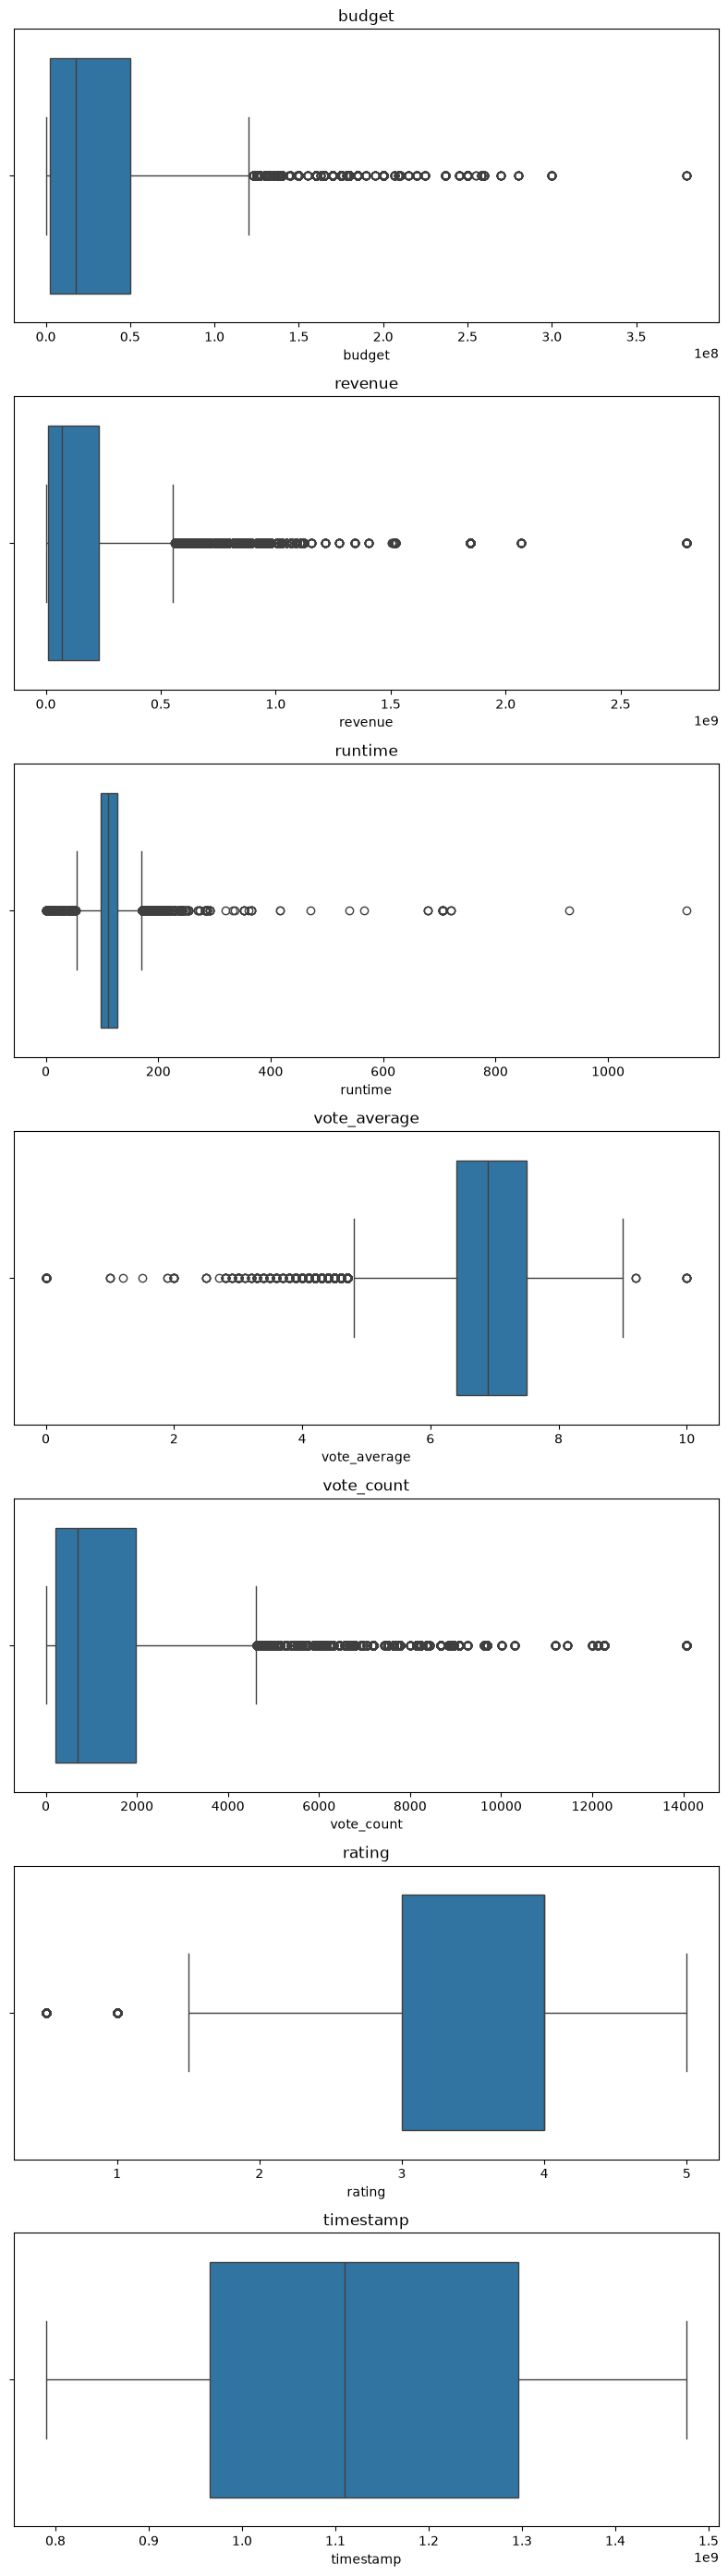

In [946]:
id_columns = ['id', 'imdbId', 'movieId', 'userId', 'tmdbId']
numeric_columns = [col for col in df.select_dtypes(include='number').columns if col not in id_columns]

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: {len(outliers)} outliers ({len(outliers) / len(df) * 100:.2f}%)")

fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(8, 4 * len(numeric_columns)))
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(x=df[column], ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()


IQR-based outliers, on the rating-level `df`: `vote_count` 8.4%, `revenue` 6.5%, `budget`
5.1%, `rating` 4.4%, `runtime` 3.8%, `vote_average` 1.5%. For a recommender these aren't
noise they're mostly popular titles, exactly what's most likely to be recommended.
`rating` and `timestamp` aren't good IQR candidates (a bounded scale and a plain
identifier, respectively) and are kept only for completeness.

In [947]:
df[df['runtime'] == 1140]

,belongs_to_collection,budget,genres,id,imdbId,original_language,original_title,popularity,production_companies,production_countries,...,title,vote_average,vote_count,cast,director,keywords,movieId,userId,rating,timestamp
97158,No belongs to collection,0,Documentary,142051,221300,en,Jazz,1.507756,,,...,Jazz,5.7,3.0,Keith David,Ken Burns,,98795,547,4.0,1355494864


The runtime maximum is a real film, Ken Burns' *Jazz*, a long-form documentary, not a
data error. Outliers are left untouched throughout: for this project they're signal, not
noise.